# Predictive Analytics Project
## Part 1: Problem Definition and Dataset Selection 
### •	Identify a specific business problem that can be addressed using predictive analytics 

**Business Problem**

Customer churn is a major issue for subscription-based businesses such as telecom operators. High churn rates lead to revenue loss and increased marketing costs, since acquiring new customers is more expensive than retaining existing ones.

**Problem definition:**

The business problem is to predict whether a customer is likely to churn (leave the company) based on their demographics, account information, and service usage. By identifying at-risk customers early, the company can implement targeted retention strategies such as special offers, discounts, or improved support, thereby reducing churn and increasing profitability.

### •	Select an appropriate dataset from Kaggle that aligns with your chosen problem 

**Dataset:** Telco Customer Churn from Kaggle.

**Size:** 7043 customers, 21 variables.

**Target variable:** Churn (Yes/No).

**Features:** Customer demographics, contract details, billing, payment method, and subscribed services.

### •	Justify your dataset selection and explain its relevance to the business problem

This dataset is ideal because:

1. Directly linked to the business problem: It contains relevant features (tenure, payment methods, contract type, service usage) that influence customer churn.

2. Well-structured for predictive analytics: Clear target variable (`Churn`), mix of categorical and numerical features.

3. Real-world relevance: Telecom companies spend millions on churn reduction, so insights from this analysis can guide actionable strategies in customer retention.

## Part 2: Exploratory Data Analysis 
### •	Perform thorough data cleaning and preprocessing 

In [37]:
# Import libraries
import pandas as pd, numpy as np, seaborn as sns
import matplotlib.pyplot as plt

In [38]:
# Load dataset
df = pd.read_csv('telco_customer_churn.csv')

In [39]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
for col in df.columns:
    print(col)

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [41]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### -----------------------------------
#### Data Cleaning & Preprocessing
#### -----------------------------------

In [43]:
# Drop customerID
df.drop('customerID', axis=1, inplace=True) # not useful for prediction

In [44]:
# Convert TotalCharges to numeric, coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [45]:
# Check for missing values
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [46]:
# Drop rows with missing TotalCharges
df.dropna(inplace=True)

In [47]:
# Encode binary categorical variables (Yes=1, No=0)

internet_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies'] # Columns with "No internet service"

# Replace "No internet service" with "No"
df[internet_cols] = df[internet_cols].replace({'No internet service': 'No'})

# Now encode binary variables (Yes=1, No=0)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling', 'Churn'] + internet_cols

for col in binary_cols:
    df[col] = df[col].replace({'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1})


C:\Users\Yahya\AppData\Local\Temp\ipykernel_14804\1940094223.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1})


In [48]:
# One-hot encode multi-category columns
multi_cat_cols = ['MultipleLines','InternetService','Contract','PaymentMethod']
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

### •	Conduct comprehensive exploratory data analysis, including:
    - Statistical summaries and distribution analysis 
    - Visualization of key relationships and patterns
    - Correlation analysis and feature importance assessment  

#### --------------------------------------
#### Statistical Summaries & Distribution
#### --------------------------------------

In [49]:
print(round(df.describe(), 2))

       gender  SeniorCitizen  Partner  Dependents   tenure  PhoneService  \
count  7032.0        7032.00  7032.00     7032.00  7032.00        7032.0   
mean      0.5           0.16     0.48        0.30    32.42           0.9   
std       0.5           0.37     0.50        0.46    24.55           0.3   
min       0.0           0.00     0.00        0.00     1.00           0.0   
25%       0.0           0.00     0.00        0.00     9.00           1.0   
50%       1.0           0.00     0.00        0.00    29.00           1.0   
75%       1.0           0.00     1.00        1.00    55.00           1.0   
max       1.0           1.00     1.00        1.00    72.00           1.0   

       OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
count         7032.00       7032.00           7032.00      7032.00   
mean             0.29          0.34              0.34         0.29   
std              0.45          0.48              0.48         0.45   
min              0.00          0.00

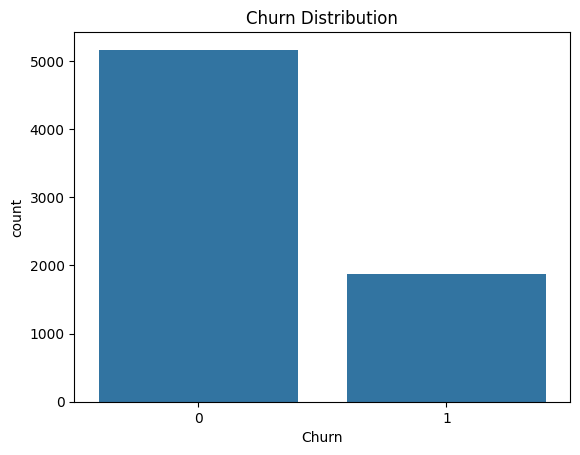

In [50]:
# Target variable distribution
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

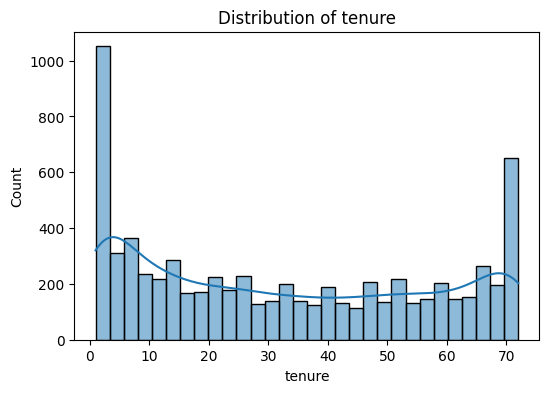

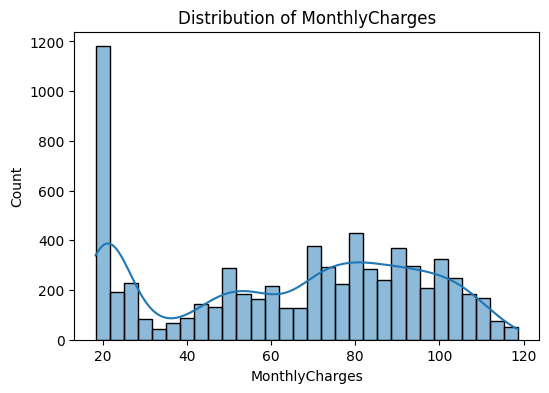

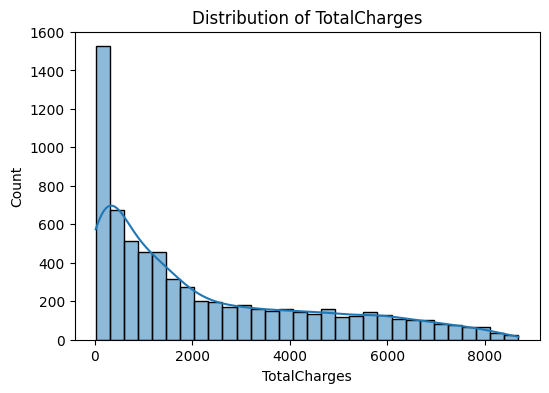

In [51]:
# Numeric variable distributions
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

#### --------------------------------------
#### Visualization of Key Relationships
#### --------------------------------------

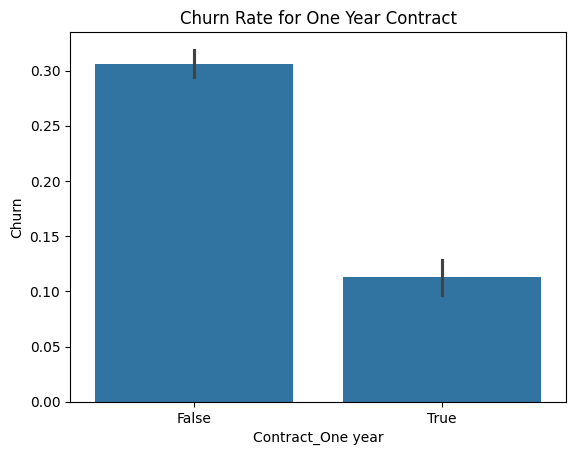

In [52]:
# Churn rate by Contract type
sns.barplot(x='Contract_One year', y='Churn', data=df)
plt.title('Churn Rate for One Year Contract')
plt.show()

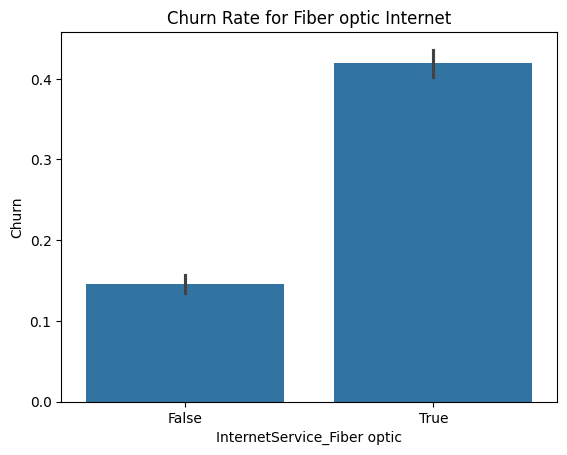

In [53]:
# Churn vs Internet Service types
sns.barplot(x='InternetService_Fiber optic', y='Churn', data=df)
plt.title('Churn Rate for Fiber optic Internet')
plt.show()

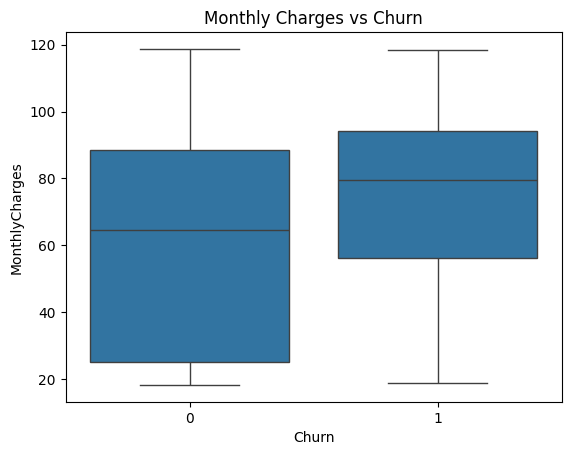

In [54]:
# Boxplot: MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

#### --------------------------------------
#### Correlation & Feature Importance
#### --------------------------------------

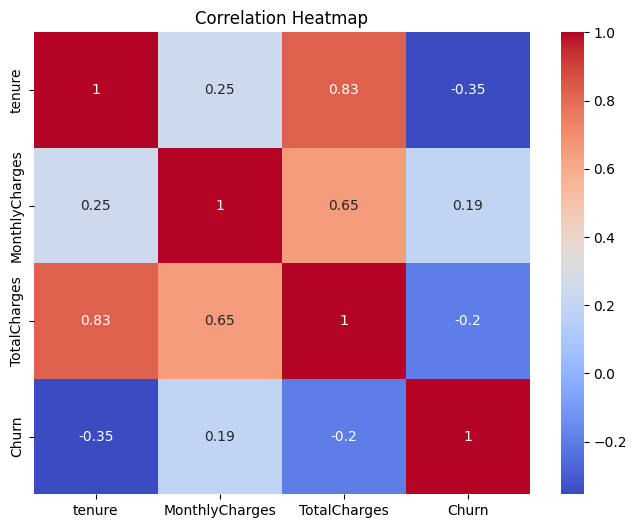

In [55]:
# Correlation heatmap for numeric features
plt.figure(figsize=(8,6))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Part 3: Feature Engineering and Model Development
### •	Engineer relevant features to improve model performance 

In [56]:
# Tenure groups
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,60,72],
                            labels=['0-12','12-24','24-48','48-60','60-72'])

df = pd.get_dummies(df, columns=['tenure_group'], drop_first=True)

# Average charges per month
df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)  # avoid division by zero

### •	Implement at least three different predictive models appropriate for your problem

I will implement three models for binary classification:

    1. Logistic Regression

    2. Random Forest Classifier

    3. XGBoost Classifier

In [57]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Split data
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### •	Perform hyperparameter tuning to optimize model performance

In [58]:
# Logistic Regression pipeline
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
pipe_lr.fit(X_train, y_train)

# Random Forest with GridSearch
rf = RandomForestClassifier(random_state=42)
rf_params = {'n_estimators':[100,200], 'max_depth':[5,10,15]}
grid_rf = GridSearchCV(rf, rf_params, cv=3, scoring='roc_auc')
grid_rf.fit(X_train, y_train)

# XGBoost with default params (can tune later)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:31:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### •	Create a data pipeline for preprocessing and model 

In [59]:
# Example pipeline for Random Forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),  # scaling optional for RF, necessary for LR
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        random_state=42))])

## Part 4: Model Evaluation and Business Insights 
### •	Evaluate models using appropriate metrics for your problem type 

In [60]:
models = {'Logistic Regression': pipe_lr,
          'Random Forest': grid_rf.best_estimator_,
          'XGBoost': xgb_model}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    print(f"---{name}---")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}\n")

---Logistic Regression---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407

ROC-AUC: 0.837

---Random Forest---
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1033
           1       0.67      0.41      0.51       374

    accuracy                           0.79      1407
   macro avg       0.74      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407

ROC-AUC: 0.840

---XGBoost---
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1033
           1       0.57      0.51      0.54       374

    accuracy                           0.77      1407
   macro avg       0.70      0.68   

### •	Compare model performance and select the best model with justification 

| Model               | Accuracy | Precision (Churn) | Recall (Churn) | F1-Score (Churn) | ROC-AUC |
| ------------------- | -------- | ----------------- | -------------- | ---------------- | ------- |
| Logistic Regression | 0.79     | 0.64              | 0.53           | 0.58             | 0.837   |
| Random Forest       | 0.79     | 0.67              | 0.41           | 0.51             | 0.840   |
| XGBoost             | 0.77     | 0.57              | 0.51           | 0.54             | 0.813   |

**Analysis:**

- `Random Forest` has the highest ROC-AUC (0.840), slightly higher precision for churn (0.67) but lower recall (0.41), meaning it’s better at correctly identifying non-churners than churners.

- `Logistic Regression` has good overall balance (accuracy 0.79, ROC-AUC 0.837) and is interpretable, but recall for churn is only 0.53.

- `XGBoost` has slightly lower performance across metrics (accuracy 0.77, ROC-AUC 0.813).

**Selection:**

`Random Forest` is selected as the best model because it achieves the highest ROC-AUC, indicating the best overall ability to distinguish between churners and non-churners. It also captures non-linear relationships and interactions between features that are important in churn prediction.

### •	Interpret model results in the context of the business problem 

In [61]:
importances = grid_rf.best_estimator_.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feature_importance.head(10))

tenure                            0.196147
InternetService_Fiber optic       0.116905
PaymentMethod_Electronic check    0.108886
Contract_Two year                 0.106284
TotalCharges                      0.102183
MonthlyCharges                    0.077284
AvgCharges                        0.055796
InternetService_No                0.045067
Contract_One year                 0.036948
tenure_group_60-72                0.034925
dtype: float64


The top 10 features influencing churn according to the Random Forest feature importance:
```sql
tenure                            0.196
InternetService_Fiber optic       0.117
PaymentMethod_Electronic check    0.109
Contract_Two year                 0.106
TotalCharges                      0.102
MonthlyCharges                    0.077
AvgCharges                        0.056
InternetService_No                0.045
Contract_One year                 0.037
tenure_group_60-72                0.035
```
**Insights:**

1. Tenure (0.196) – Customers who have been with the company for a shorter time are more likely to churn.

2. InternetService_Fiber optic (0.117) – Customers using fiber optic internet have higher churn probability, possibly due to higher costs or service issues.

3. PaymentMethod_Electronic check (0.109) – Customers paying via electronic checks are more likely to churn than those using other payment methods.

4. Contract type (0.106 and 0.037) – Month-to-month contracts (implicitly captured in model) are more likely to churn than one- or two-year contracts.

5. TotalCharges and MonthlyCharges – High charges can increase churn risk if customers perceive value as low.

**Business Implications:**

- Retention strategies: Focus on short-tenure customers and those on month-to-month contracts with high monthly charges.

- Service incentives: Offer special deals or loyalty programs for fiber optic users at higher risk.

- Payment method interventions: Encourage safer, recurring payment methods for at-risk customers.

- Bundling services: Bundle multiple services to increase customer stickiness and reduce churn likelihood.